# Real Data 
(Daniel: file 104)

In [19]:
from pathlib import Path
import os, sys

# Ensure a common Results/ folder next to Experiments/
cwd = Path.cwd().resolve()
if cwd.name == "Experiments" and (cwd.parent / "helpers").exists():
    PROJECT_ROOT = cwd.parent
elif (cwd / "helpers").exists():
    PROJECT_ROOT = cwd
elif (cwd / "MICRO-489_SMLM_tracking" / "helpers").exists():
    PROJECT_ROOT = cwd / "MICRO-489_SMLM_tracking"
else:
    raise RuntimeError(f"Could not find project root from {cwd}")

OUT_DIR = PROJECT_ROOT / "Results"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Results directory: {OUT_DIR}")

Results directory: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Results


In [20]:
%cd ..
from helpers.helpersGeneration import *
from helpers.helpersSimulation import *
from helpers.helpersTracking import *
from helpers.helpersStatistics import *
from helpers.helpersAssignment import *
from helpers.helpersPlotting import *

c:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking


In [21]:
import tifffile as tiff
import numpy as np

# Path to the TIFF relative to your script
tif_path = PROJECT_ROOT / "Data" / "frames_104.tif"

# Load the full TIFF stack (1000 frames)
frames_full = tiff.imread(tif_path)

# Extract a given amount of frames
start_f = 210
end_f = 235
frames = frames_full[start_f:end_f]

# Ensure float32 dtype (your simulated pipeline uses float32)
frames = frames.astype(np.float32)

print("Loaded frames:", frames.shape, frames.dtype)

Loaded frames: (25, 128, 128) float32


In [43]:
animate_video(frames, interval=100, vmin=500, vmax=2780)

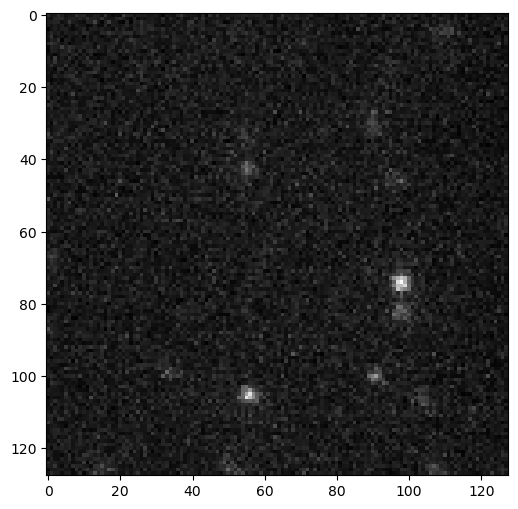

In [51]:
def show_frame(frame, vmin=None, vmax=None, figsize=(6,6)):
    plt.figure(figsize=figsize)
    plt.imshow(frame, cmap='gray', vmin=vmin, vmax=vmax)

show_frame(frames[24])

In [41]:
%cd MICRO-489_SMLM_tracking
save_video_as_gif(frames, "real_210_235.gif", fps=10)

c:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking


In [23]:
# permissive thresholds for real data
DETECTION_THRESHOLD = 2500
R_SQUARED_THRESHOLD = 0.3

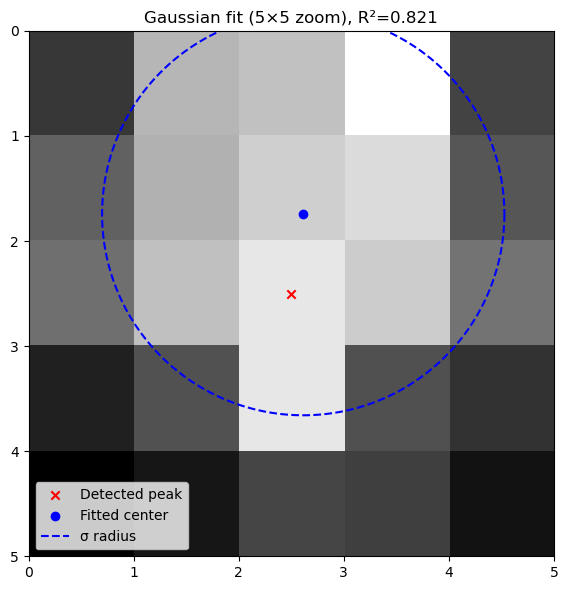

[Frame 1] No computed R-squared for peak at (1, 91).
[Frame 2] Poor fit for peak at (106, 54): R-squared = 0.220 (below threshold of 0.3).
[Frame 2] Poor fit for peak at (67, 99): R-squared = 0.169 (below threshold of 0.3).
[Frame 2] Poor fit for peak at (68, 101): R-squared = 0.254 (below threshold of 0.3).
[Frame 3] No computed R-squared for peak at (97, 33).
[Frame 3] Poor fit for peak at (34, 59): R-squared = 0.201 (below threshold of 0.3).
[Frame 4] Poor fit for peak at (102, 55): R-squared = 0.225 (below threshold of 0.3).
[Frame 4] Poor fit for peak at (99, 32): R-squared = 0.191 (below threshold of 0.3).
[Frame 5] No computed R-squared for peak at (101, 50).
[Frame 6] No computed R-squared for peak at (76, 99).
[Frame 6] Poor fit for peak at (71, 102): R-squared = 0.104 (below threshold of 0.3).
[Frame 7] No computed R-squared for peak at (56, 91).
[Frame 7] Poor fit for peak at (78, 97): R-squared = 0.020 (below threshold of 0.3).
[Frame 8] No computed R-squared for peak at (4

In [24]:
# Detect, localize and track particles (regular pipeline)
(
    trajectories_localization,
    cost_peak2peak,
    assignment_output,
    cost_traj2traj,
) = track(
    frames,
    trajectories_GT=None,
    mode="localization",

    # detection
    detection_threshold=DETECTION_THRESHOLD,

    # linking
    max_distance=10,
    min_length=5,
    max_gap=5,

    # stitching
    stitch_fragments=False,
    stitch_max_gap=5,
    stitch_base_distance=10.0,
    stitch_kwargs=None,
    verbose_stitching=True,

    # localization quality
    r_squared_threshold=R_SQUARED_THRESHOLD,

    # peak-to-peak assignment
    algo_peak2peak="hungarian",
    cost_func_peak2peak=None,

    # trajectory-to-trajectory assignment
    algo_traj2traj="hungarian",
    cost_func_traj2traj=None,

    # verbosity / visualization
    verbose_loc=True,
    visualization_loc=True,
    verbose_assignment=True,
)

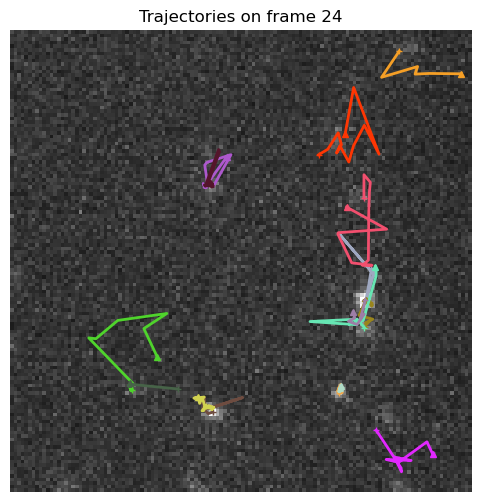

In [25]:
show_trajectories(frames, trajectories_localization, frame_id=(end_f - start_f)-1)

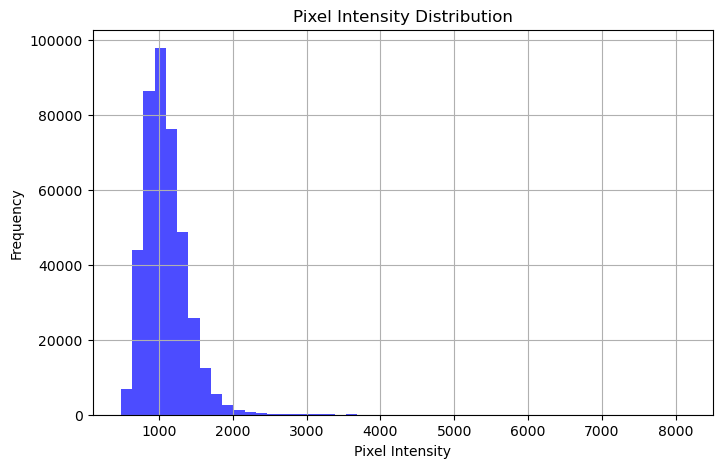

In [26]:
def show_histogram(frames):
    plt.figure(figsize=(8, 5))
    plt.hist(frames.flatten(), bins=50, color="blue", alpha=0.7)
    plt.title("Pixel Intensity Distribution")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

show_histogram(frames)

In [27]:
# compute average trajectory length
all_lengths = [traj.length() for traj in trajectories_localization]
print("Trajectory lengths:", all_lengths)
avg_length = np.mean(all_lengths)
print(f"Average trajectory length: {avg_length:.2f} frames")

Trajectory lengths: [10, 22, 17, 12, 11, 14, 11, 20, 13, 19, 18, 10, 9, 12, 6, 8]
Average trajectory length: 13.25 frames


## Test patch extraction

In [28]:
# extract patches
patches = extract_patches_per_id(frames, trajectories_localization, traj_id=6)

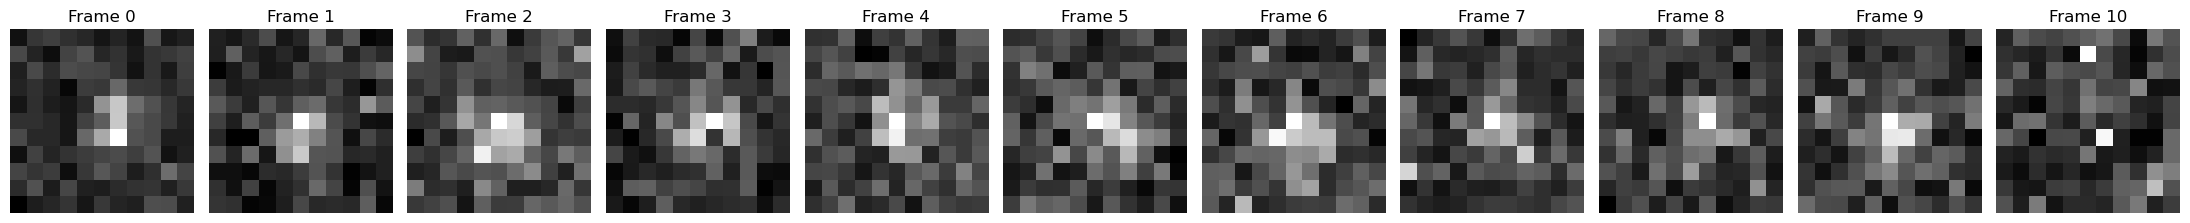

In [29]:
visualize_particle_patches(patches)

11 detected peaks: [((74.0, 98.0), 5925.0, None), ((106.0, 55.0), 5352.0, None), ((76.0, 97.0), 4731.0, None), ((100.0, 91.0), 3818.0, None), ((43.0, 55.0), 3009.0, None), ((81.0, 97.0), 2888.0, None), ((46.0, 98.0), 2789.0, None), ((41.0, 55.0), 2777.0, None), ((83.0, 96.0), 2751.0, None), ((126.0, 50.0), 2704.0, None), ((99.0, 33.0), 2685.0, None)]


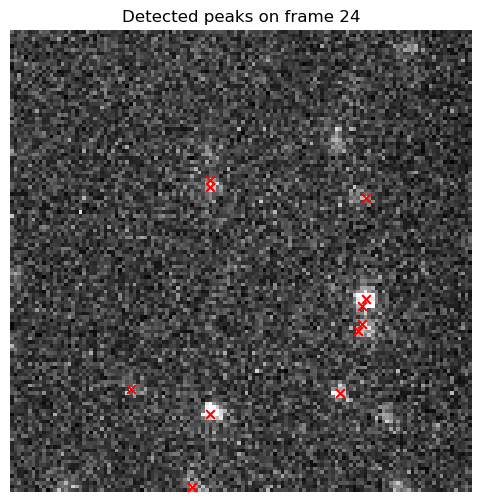

In [31]:
# get detected peaks
detected_peaks = extract_peaks(frames, mode='detection', detection_threshold=2500)


def show_detections_on_frame(frame, detected_peaks, frame_id=0,
                             vmin=None, vmax=None, figsize=(6,6)):
    """
    frame: 2D numpy array (single frame)
    detected_peaks: list of lists of peaks, each peak = ((x,y), intensity, sigma)
    frame_id: which frame to visualize
    """
    peaks = detected_peaks[frame_id]

    xs = [p[0][1] for p in peaks]   # p[0] = (x,y)
    ys = [p[0][0] for p in peaks]

    plt.figure(figsize=figsize)
    plt.imshow(frame, cmap='gray', vmin=vmin, vmax=vmax)
    plt.scatter(xs, ys, color='red', marker='x', s=40)
    plt.title(f"Detected peaks on frame {frame_id}")
    plt.axis('off')
    plt.show()

frame_id = end_f - start_f - 1
print(len(detected_peaks[frame_id]), "detected peaks:", detected_peaks[frame_id])
show_detections_on_frame(frames[frame_id], detected_peaks, frame_id=frame_id,
                         vmin=500, vmax=2780)

## Test separated pipeline on real data

In [32]:
# tracking only immobile particles, that is within 2 pixels moving distance
loc_results_sep = track(
    frames,
    trajectories_GT=None,
    mode="localization",
    detection_threshold=DETECTION_THRESHOLD,
    max_distance=2,
    min_length=5,
    max_gap=5,
    stitch_fragments=True,
    stitch_max_gap=5,
    stitch_base_distance=10.0,
    stitch_kwargs=None,
    verbose_stitching=True,
    r_squared_threshold=R_SQUARED_THRESHOLD,
    algo_peak2peak="hungarian",
    cost_func_peak2peak=None,
    algo_traj2traj="hungarian",
    cost_func_traj2traj=None,
    verbose_loc=True,
    visualization_loc=False,
    verbose_assignment=True,
)

print(f"Found {len(loc_results_sep[0])} static particles.")

static_trajs_loc_sep = loc_results_sep[0]

# now extract all peaks
peaks_for_tracking_sep = extract_peaks(
                        frames, 
                        mode='localization', 
                        detection_threshold=DETECTION_THRESHOLD, 
                        r_squared_threshold=R_SQUARED_THRESHOLD, 
                        verbose_loc=False, 
                        visualization_loc=False
                     )

# remove peaks corresponding to static trajectories
mobile_peaks_for_tracking_sep = remove_static_peaks(peaks_for_tracking_sep, static_trajs_loc_sep, tolerance=5.0, verbose=True)


# track with regular pipeline on the remaining mobile trajectories
trajs_loc_sep, cost_peak2peak_sep, assignment_output_sep, cost_traj2traj_sep = track_from_peaks(
                                                                                mobile_peaks_for_tracking_sep, 
                                                                                trajectories_GT=None, 
                                                                                max_distance=10, 
                                                                                min_length=5, 
                                                                                max_gap=5,
                                                                                stitch_fragments=True,
                                                                                stitch_max_gap=5,
                                                                                stitch_base_distance=10.0,
                                                                                stitch_kwargs=None,
                                                                                verbose_stitching=True,
                                                                                algo_peak2peak="hungarian", 
                                                                                cost_func_peak2peak=None, 
                                                                                algo_traj2traj="hungarian", 
                                                                                cost_func_traj2traj=None, 
                                                                                verbose_assignment=True)

# add back the static trajectories to the mobile ones to have the full set of trajectories for evaluation
trajs_loc_sep += static_trajs_loc_sep

[Frame 1] No computed R-squared for peak at (1, 91).
[Frame 2] Poor fit for peak at (106, 54): R-squared = 0.220 (below threshold of 0.3).
[Frame 2] Poor fit for peak at (67, 99): R-squared = 0.169 (below threshold of 0.3).
[Frame 2] Poor fit for peak at (68, 101): R-squared = 0.254 (below threshold of 0.3).
[Frame 3] No computed R-squared for peak at (97, 33).
[Frame 3] Poor fit for peak at (34, 59): R-squared = 0.201 (below threshold of 0.3).
[Frame 4] Poor fit for peak at (102, 55): R-squared = 0.225 (below threshold of 0.3).
[Frame 4] Poor fit for peak at (99, 32): R-squared = 0.191 (below threshold of 0.3).
[Frame 5] No computed R-squared for peak at (101, 50).
[Frame 6] No computed R-squared for peak at (76, 99).
[Frame 6] Poor fit for peak at (71, 102): R-squared = 0.104 (below threshold of 0.3).
[Frame 7] No computed R-squared for peak at (56, 91).
[Frame 7] Poor fit for peak at (78, 97): R-squared = 0.020 (below threshold of 0.3).
[Frame 8] No computed R-squared for peak at (4

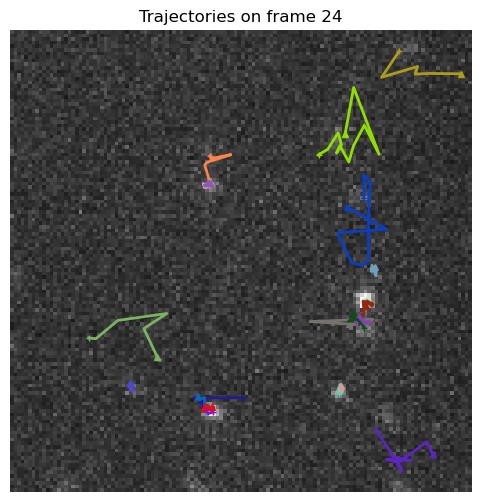

In [33]:
show_trajectories(frames, trajs_loc_sep, frame_id=(end_f - start_f)-1)